In [1]:
# Memastikan GPU sudah terpasang di device
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

True
11.8
NVIDIA GeForce GTX 1650 Ti


In [2]:
# Menyimpan semua gambar yang benar-benar ada anotasi dan menampilkan gambar tanpa anotasi
import os
import shutil

images_dir = "TrafficDataset/images/train"
labels_dir = "TrafficDataset/labels/train"

output_images = "filtered_dataset/images"
output_labels = "filtered_dataset/labels"

os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

saved = 0
empty = 0

for img in os.listdir(images_dir):

    if not img.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    name = os.path.splitext(img)[0]

    label_path = os.path.join(labels_dir, name + ".txt")
    image_path = os.path.join(images_dir, img)

    if os.path.exists(label_path):

        # cek apakah label kosong
        if os.path.getsize(label_path) > 0:

            shutil.copy(image_path, output_images)
            shutil.copy(label_path, output_labels)

            saved += 1

        else:
            empty += 1

print("Gambar tersimpan dengan bounding box:", saved)
print("Gambar dengan anotasi yang kosong:", empty)

Gambar tersimpan dengan bounding box: 732
Gambar dengan anotasi yang kosong: 6


In [3]:
# Mengecek Distribusi Kelas Dataset Awal
import os
from collections import Counter

labels_dir = "TrafficDataset/labels/train"

class_map = {
    0: "car",
    1: "bus",
    2: "truck"
}

allowed_classes = {0,1,2}
class_counts = Counter()

for file in os.listdir(labels_dir):

    if not file.endswith(".txt"):
        continue

    path = os.path.join(labels_dir, file)

    with open(path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) == 0:
            continue

        cls = int(parts[0])
        if cls in allowed_classes:
            class_counts[cls] += 1

print("\nDistribusi kelas dataset awal:")
for cls_id, count in class_counts.items():
    print(f"{class_map.get(cls_id,'unknown')}: {count}")


Distribusi kelas dataset awal:
truck: 1149
car: 4116
bus: 479


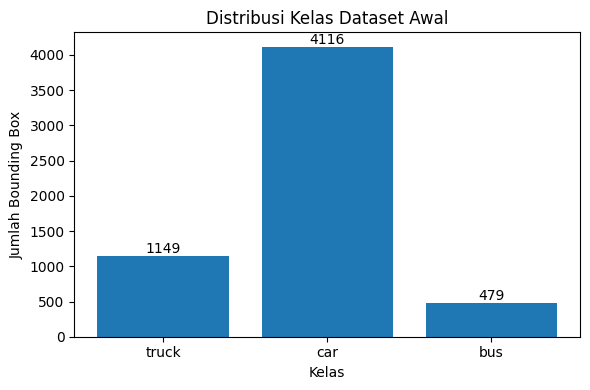

In [4]:
import matplotlib.pyplot as plt

classes = [class_map[c] for c in class_counts.keys()]
counts = list(class_counts.values())
plt.figure(figsize=(6,4))
bars = plt.bar(classes, counts)

plt.title("Distribusi Kelas Dataset Awal")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Bounding Box")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{int(height)}",
             ha="center",
             va="bottom")

plt.tight_layout()
plt.savefig("distribusi_kelas_awal.png", dpi=300)
plt.show()

In [5]:
# Hapus gambar yang rusak/corrupt
import cv2
images_dir = "filtered_dataset/images/train"

for file in os.listdir(images_dir):

    path = os.path.join(images_dir,file)

    img = cv2.imread(path)

    if img is None:
        print("Corrupted image:",file)

In [7]:
# Menampilkan hanya gambar yang memiliki bounding box saja dan simpan gambar tanpa bounding box sama sekali
import os
import cv2

images_dir = "filtered_dataset/images/train"
labels_dir = "filtered_dataset/labels/train"

classes = ["car", "bus", "truck"]

shown = 0

for img_name in os.listdir(images_dir):

    if not img_name.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + ".txt")

    # skip jika tidak ada label
    if not os.path.exists(label_path):
        continue

    # skip jika label kosong
    if os.path.getsize(label_path) == 0:
        continue

    image_path = os.path.join(images_dir, img_name)
    image = cv2.imread(image_path)

    h, w, _ = image.shape

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cls = int(cls)

        # skip jika class bukan car, bus, truck
        if cls >= len(classes):
            continue
        
        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(image, classes[cls], (x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    cv2.imshow("Annotated Image", image)

    shown += 1

    key = cv2.waitKey(0)

    if key == 27:  # ESC untuk keluar
        break

cv2.destroyAllWindows()

print("Jumlah gambar dengan anotasi yang ditampilkan:", shown)

Jumlah gambar dengan anotasi yang ditampilkan: 357


In [ ]:
# Memfilter Kelas yang tidak diinginkan dan hapus kotak kosong
labels_dir = "filtered_dataset/labels"

allowed_classes = {0, 1, 2}   # car bus truck

files_checked = 0
boxes_removed = 0
removed_classes = 0

for root, dirs, files in os.walk(labels_dir):

    for file in files:

        if not file.endswith(".txt"):
            continue

        path = os.path.join(root, file)

        new_lines = []

        with open(path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls, x, y, w, h = map(float, parts)

            # skip kelas yang tidak diinginkan
            if int(cls) not in allowed_classes:
                removed_classes += 1
                continue

            # skip kotak kosong
            if w == 0 or h == 0:
                boxes_removed += 1
                continue

            new_lines.append(line)

        with open(path, "w") as f:
            f.writelines(new_lines)

        files_checked += 1

print("File diperiksa:", files_checked)
print("Bounding box kosong dihapus:", boxes_removed)
print("Baris kelas tidak diinginkan dihapus:", removed_classes)

File diperiksa: 2822
Bounding box kosong dihapus: 1
Baris kelas tidak diinginkan dihapus: 3410


In [66]:
# Memvalidasi kelas yang benar-benar ada setelah filtering
labels_dir = "filtered_dataset/labels"

classes_found = set()
allowed = {0, 1, 2}

for root, dirs, files in os.walk(labels_dir):

    for file in files:

        if not file.endswith(".txt"):
            continue

        path = os.path.join(root, file)

        with open(path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) == 0:
                continue

            cls = int(parts[0])
            classes_found.add(cls)

found_allowed = sorted(classes_found & allowed)
print("Kelas yang ditemukan dalam dataset: ", found_allowed)
missing = sorted(allowed - classes_found)
if missing:
    print("Kelas yang tidak ada:", missing)

Kelas yang ditemukan dalam dataset:  [0, 1, 2]


In [67]:
# === HAPUS/BERSIHKAN FILE OVERSAMPLING LAMA ===
import os

labels_dir = "filtered_dataset/labels"
images_dir = "filtered_dataset/images"

deleted = 0

for folder in [labels_dir, images_dir]:

    for root, dirs, files in os.walk(folder):

        for file in files:

            if "_dup" in file:
                os.remove(os.path.join(root, file))
                deleted += 1

print("File oversampling lama yang dihapus:", deleted)

File oversampling lama yang dihapus: 0


In [68]:
# === TAHAPAN OVERSAMPLING ===
# Duplikasi truk dan bus sebelum memisahkan dataset

labels_dir = "filtered_dataset/labels"
images_dir = "filtered_dataset/images"

target_classes = {1, 2}   # 1 = bus, 2 = truck
oversample_factor = 2

files_to_oversample = []

# membaca semua label termasuk di subfolder
for root, dirs, files in os.walk(labels_dir):

    for label_file in files:

        if not label_file.endswith(".txt"):
            continue
            # SKIP file hasil oversampling sebelumnya
        if "_dup" in label_file:
            continue
        
        label_path = os.path.join(root, label_file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        classes = [int(line.split()[0]) for line in lines if line.strip()]

        # cek apakah ada bus atau truck
        if any(c in target_classes for c in classes):

            image_file = label_file.replace(".txt", ".jpg")
            image_path = os.path.join(images_dir, image_file)

            if os.path.exists(image_path):
                files_to_oversample.append((image_file, label_file))

print("Jumlah file yang akan di-oversample:", len(files_to_oversample))

# proses duplikasi
for image_file, label_file in files_to_oversample:

    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    # hanya simpan label bus dan truck
    filtered_lines = [
        line for line in lines
        if int(line.split()[0]) in target_classes
    ]

    for i in range(oversample_factor):

        new_image = image_file.replace(".jpg", f"_dup{i}.jpg")
        new_label = label_file.replace(".txt", f"_dup{i}.txt")

        # copy gambar
        shutil.copy(image_path, os.path.join(images_dir, new_image))

        # tulis label baru (tanpa car)
        with open(os.path.join(labels_dir, new_label), "w") as f:
            f.writelines(filtered_lines)

print("Oversampling bus & truck selesai!")

print("Jumlah label setelah oversampling:",
      len([f for f in os.listdir(labels_dir) if f.endswith(".txt")]))

Jumlah file yang akan di-oversample: 2027
Oversampling bus & truck selesai!
Jumlah label setelah oversampling: 1784


In [69]:
# Memeriksa kembali distribusi kelas setelah filtering dan oversampling
labels_dir = "filtered_dataset/labels"

class_map = {
    0: "car",
    1: "bus",
    2: "truck"
}

allowed_classes = {0,1,2}
class_counts = Counter()

for file in os.listdir(labels_dir):

    if not file.endswith(".txt"):
        continue

    path = os.path.join(labels_dir, file)

    with open(path, "r") as f:
        lines = f.readlines()

    for line in lines:

        parts = line.strip().split()
        if len(parts) != 5:   # memastikan format YOLO benar
            continue

        cls = int(parts[0])

        if cls in allowed_classes:
            class_counts[cls] += 1


print("\nDistribusi kelas dataset setelah oversampling:")

for cls_id in sorted(class_map.keys()):
    print(f"{class_map[cls_id]}: {class_counts.get(cls_id,0)}")

print("\nTotal bounding box:", sum(class_counts.values()))
print("Total file label:", len([f for f in os.listdir(labels_dir) if f.endswith(".txt")]))


Distribusi kelas dataset setelah oversampling:
car: 4116
bus: 1321
truck: 3310

Total bounding box: 8747
Total file label: 1784


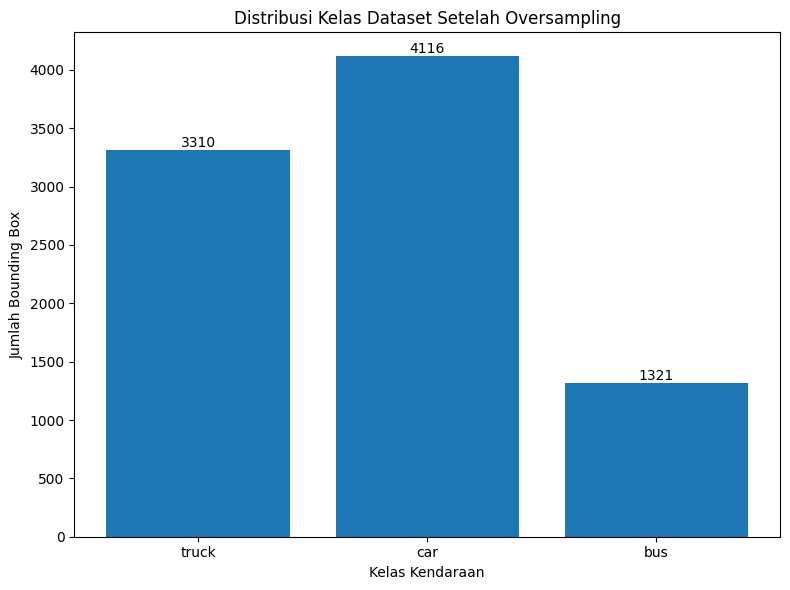

In [70]:
from collections import Counter
classes = [class_map[c] for c in class_counts.keys()]
counts = list(class_counts.values())
plt.figure(figsize=(8,6))

bars = plt.bar(classes, counts)

plt.title("Distribusi Kelas Dataset Setelah Oversampling")
plt.xlabel("Kelas Kendaraan")
plt.ylabel("Jumlah Bounding Box")

# menampilkan angka di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{int(height)}",
             ha="center",
             va="bottom")

plt.tight_layout()
plt.savefig("distribusi_kelas_setelah_oversampling.png", dpi=300)
plt.show()

In [71]:
# Memisahkan dataset menjadi train/val/test
import random
images_dir = "filtered_dataset/images"
labels_dir = "filtered_dataset/labels"

train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

images = [f for f in os.listdir(images_dir) if f.endswith((".jpg",".png",".jpeg"))]

random.shuffle(images)

total = len(images)

train_split = int(total * train_ratio)
val_split = int(total * (train_ratio + val_ratio))

train_files = images[:train_split]
val_files = images[train_split:val_split]
test_files = images[val_split:]

def move_files(file_list, split):

    os.makedirs(f"filtered_dataset/images/{split}", exist_ok=True)
    os.makedirs(f"filtered_dataset/labels/{split}", exist_ok=True)

    for img in file_list:

        name = os.path.splitext(img)[0]

        shutil.move(
            os.path.join(images_dir, img),
            f"filtered_dataset/images/{split}/{img}"
        )

        label = name + ".txt"

        if os.path.exists(os.path.join(labels_dir, label)):
            shutil.move(
                os.path.join(labels_dir, label),
                f"filtered_dataset/labels/{split}/{label}"
            )

move_files(train_files,"train")
move_files(val_files,"val")
move_files(test_files,"test")

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 1248
Val: 357
Test: 179


In [72]:
# Membersihkan format penulisan kordinat anotasi label pada filtered dataset yang tidak sesuai dengan format YOLO
base_dir = "filtered_dataset/labels"

files_checked = 0
invalid_lines_removed = 0

for root, dirs, files in os.walk(base_dir):

    for file in files:

        if not file.endswith(".txt"):
            continue

        path = os.path.join(root, file)

        new_lines = []

        with open(path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                invalid_lines_removed += 1
                continue

            new_lines.append(line)

        with open(path, "w") as f:
            f.writelines(new_lines)

        files_checked += 1

print("Total label diperiksa:", files_checked)
print("Anotasi rusak dihapus:", invalid_lines_removed)

Total label diperiksa: 3159
Anotasi rusak dihapus: 0


In [73]:
# Memvalidasi dan membersihkan data agar siap untuk pelatihan YOLOv10/11
# ===== PATH DATASET =====
labels_path = r"filtered_dataset/labels/train"
images_path = r"filtered_dataset/images/train"

# ===== JUMLAH KELAS =====
NUM_CLASSES = 3

errors = []
checked_files = 0

for label_file in os.listdir(labels_path):

    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(labels_path, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for i, line in enumerate(lines):

        parts = line.strip().split()

        # cek jumlah kolom
        if len(parts) != 5:
            errors.append(f"{label_file} line {i+1} format salah")
            continue

        cls, x, y, w, h = parts

        try:
            cls = int(cls)
            x, y, w, h = map(float, (x, y, w, h))
        except:
            errors.append(f"{label_file} line {i+1} tidak bisa di-parse")
            continue

        # cek class range
        if cls < 0 or cls >= NUM_CLASSES:
            errors.append(f"{label_file} line {i+1} class out of range")
            continue

        # clamp normalisasi ke [0,1]
        x = min(max(x, 0.0), 1.0)
        y = min(max(y, 0.0), 1.0)
        w = min(max(w, 0.0), 1.0)
        h = min(max(h, 0.0), 1.0)

        # cek bounding box kosong
        if w == 0 or h == 0:
            errors.append(f"{label_file} line {i+1} bbox kosong")
            continue

        new_lines.append(f"{cls} {x} {y} {w} {h}\n")

    # tulis ulang file dengan baris yang valid
    with open(label_path, "w") as f:
        f.writelines(new_lines)

    checked_files += 1


print("================================")
print("Jumlah File yang diperiksa :", checked_files)
print("Jumlah Eror yang terdapat :", len(errors))
print("================================")

for e in errors[:20]:
    print(e)

if len(errors) == 0:
    print("Dataset aman untuk training YOLO (v10/v11 siap!)")
else:
    print("Beberapa baris dibersihkan; jalankan lagi untuk memastikan.")

# Memeriksa jumlah gambar dan label sebelum pelatihan dan validasi
print("Total images:", len(os.listdir("filtered_dataset/images/train")))
print("Total labels:", len(os.listdir("filtered_dataset/labels/train")))
print("Val images:", len(os.listdir("filtered_dataset/images/val")))
print("Val labels:", len(os.listdir("filtered_dataset/labels/val")))

Jumlah File yang diperiksa : 1467
Jumlah Eror yang terdapat : 0
Dataset aman untuk training YOLO (v10/v11 siap!)
Total images: 1467
Total labels: 1467
Val images: 933
Val labels: 933


In [74]:
# Training YOLOv10 & YOLOv11 baseline
from ultralytics import YOLO
model10_base = YOLO("yolov10n.pt")
model10_base.train(
    data="data.yaml",
    epochs=40,
    imgsz=640,
    batch=4,
    device=0,
    patience = 10,
    seed = 42,
    workers = 2,
    project = "runs/detect",   # directory asal usul
    name = "train10_baseline", # nama folder yang sudah terfixkan
    exist_ok = True            # memungkinkan untuk menimpa file lama dengan nama yang sama
)

model11_base = YOLO("yolo11n.pt")
model11_base.train(
    data="data.yaml",
    epochs=40,
    imgsz=640,
    batch=4,
    device=0,
    patience = 10,
    seed = 42,
    workers = 2,
    project = "runs/detect",   
    name = "train11_baseline",          
    exist_ok = True            
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.10.11 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train10_baseline, nbs=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026C2C7D0850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [75]:
# Training Yolov11 Fine-Tuning

model11_ft = YOLO("yolo11n.pt")
model11_ft.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=4,
    device=0,
    patience=10,
    lr0=0.001,
    freeze=10,
    seed = 42,
    workers = 2,
    project="runs/detect",
    name="train11_finetune",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.10.11 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train11_finetune, nbs=64,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026CB15CD360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [77]:
# Evaluasi model menggunakan mAP, precision, recall (seluruh kelas dan kelas per kelas) model Yolov10 dan Yolov11
model10_base = YOLO(r"C:\Users\darre\runs\detect\runs\detect\train10_baseline\weights\best.pt")
metrics10_base = model10_base.val(data="data.yaml", split="test")

# === Evaluasi YOLOv10n baseline ===
print("\n=== Evaluasi Yolov10 Baseline: ===")
print(f"Precision: {metrics10_base.box.mp:.4f}")
print(f"Recall: {metrics10_base.box.mr:.4f}")
print(f"mAP50: {metrics10_base.box.map50:.4f}")
print(f"mAP50-95: {metrics10_base.box.map:.4f}")

print("\n=== Hasil per Kelas (Yolov10 Baseline): ===")
for i, name in model10_base.names.items():
    print(f"{name}: \nPrecision={metrics10_base.box.p[i]:.4f}, Recall={metrics10_base.box.r[i]:.4f}, "
          f"mAP50={metrics10_base.box.ap50[i]:.4f}, mAP50-95={metrics10_base.box.ap[i]:.4f}")
    
# === Evaluasi YOLO11n baseline ===
model11_base = YOLO(r"C:\Users\darre\runs\detect\runs\detect\train11_baseline\weights\best.pt")
metrics11_base = model11_base.val(data="data.yaml", split="test")

print("\n=== Evaluasi Yolov11 Baseline: ===")
print(f"Precision: {metrics11_base.box.mp:.4f}")
print(f"Recall: {metrics11_base.box.mr:.4f}")
print(f"mAP50: {metrics11_base.box.map50:.4f}")
print(f"mAP50-95: {metrics11_base.box.map:.4f}")

print("\n=== Hasil per Kelas (Yolov11 Baseline): ===")
for i, name in model11_base.names.items():
    print(f"{name}: \nPrecision={metrics11_base.box.p[i]:.4f}, Recall={metrics11_base.box.r[i]:.4f}, "
          f"mAP50={metrics11_base.box.ap50[i]:.4f}, mAP50-95={metrics11_base.box.ap[i]:.4f}")
    
# Evaluasi YOLOv11 FINE-TUNED
model11_ft = YOLO(r"C:\Users\darre\runs\detect\runs\detect\train11_finetune\weights\best.pt")
metrics11_ft = model11_ft.val(data="data.yaml", split="test")

print("\n=== Evaluasi YOLOv11 Fine-Tuned: ===")
print(f"Precision: {metrics11_ft.box.mp:.4f}")
print(f"Recall: {metrics11_ft.box.mr:.4f}")
print(f"mAP50: {metrics11_ft.box.map50:.4f}")
print(f"mAP50-95: {metrics11_ft.box.map:.4f}")

print("\n=== Hasil per Kelas (YOLOv11 Fine-Tuned): ===")
for i, name in model11_ft.names.items():
    print(f"{name}: \nPrecision={metrics11_ft.box.p[i]:.4f}, Recall={metrics11_ft.box.r[i]:.4f}, "
          f"mAP50={metrics11_ft.box.ap50[i]:.4f}, mAP50-95={metrics11_ft.box.ap[i]:.4f}")

Ultralytics 8.4.19  Python-3.10.11 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)
YOLOv10n summary (fused): 102 layers, 2,265,753 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 273.075.4 MB/s, size: 195.0 KB)
val: Scanning C:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Project\filtered_dataset\labels\test.cache... 759 images, 70 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 759/759  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 6.1it/s 7.9s0.2s
                   all        759       5401      0.764      0.886      0.889      0.586
                   car        516       3642      0.785      0.767      0.796      0.648
                   bus        303        501      0.758      0.986      0.963      0.644
                 truck        485       1258      0.748      0.906      0.909      0.467
Speed: 1.4ms preproces

Grafik berhasil disimpan di: perbandingan_performa_model_yolo.png


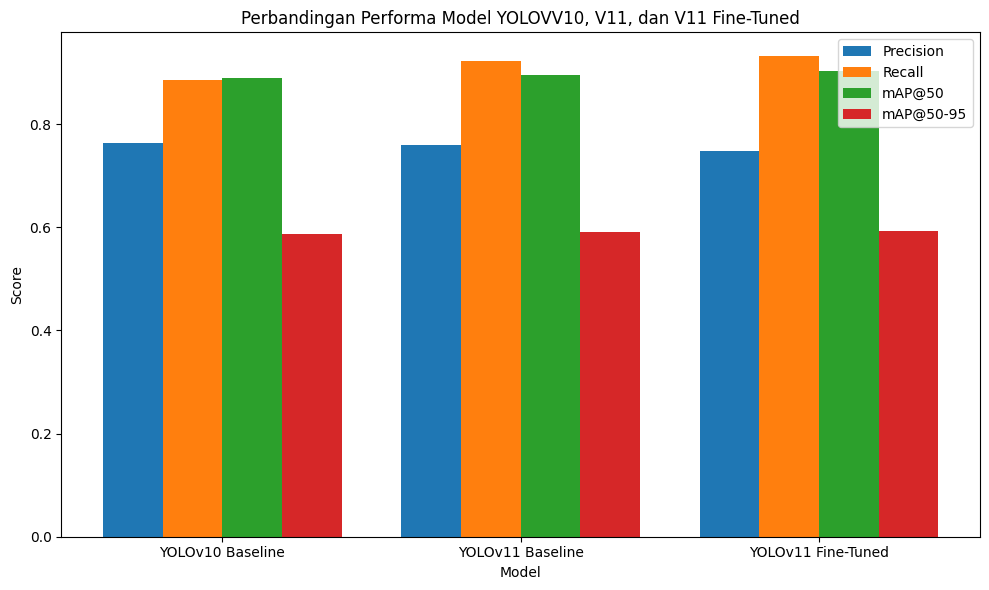

In [78]:
# Menggambar Bar Chart Hasil Metrik Evaluasi map50, map50-95, precision, recall untuk seluruh model
import matplotlib.pyplot as plt
import numpy as np

# Menyusun data metrik evaluasi

models = ["YOLOv10 Baseline", "YOLOv11 Baseline", "YOLOv11 Fine-Tuned"]

precision = [
    metrics10_base.box.mp,
    metrics11_base.box.mp,
    metrics11_ft.box.mp
]

recall = [
    metrics10_base.box.mr,
    metrics11_base.box.mr,
    metrics11_ft.box.mr
]

map50 = [
    metrics10_base.box.map50,
    metrics11_base.box.map50,
    metrics11_ft.box.map50
]

map5095 = [
    metrics10_base.box.map,
    metrics11_base.box.map,
    metrics11_ft.box.map
]

# Membuat Bar Chart hasil secara keseluruhan setiap model

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, precision, width, label="Precision")
plt.bar(x - 0.5*width, recall, width, label="Recall")
plt.bar(x + 0.5*width, map50, width, label="mAP@50")
plt.bar(x + 1.5*width, map5095, width, label="mAP@50-95")

plt.xticks(x, models)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Perbandingan Performa Model YOLOVV10, V11, dan V11 Fine-Tuned")
plt.legend()

plt.tight_layout()

# Menyimpan grafik ke komputer
save_path = "perbandingan_performa_model_yolo.png"
plt.savefig(save_path, dpi=300)

print(f"Grafik berhasil disimpan di: {save_path}")
plt.show()

In [83]:
# Menghitung Frame per Second pada model Yolov10 dan Yolov11
import time
import cv2
import random
# Memuat model baseline + fine-tuned
model10_base = YOLO(r"C:\Users\darre\runs\detect\runs\detect\train10_baseline\weights\best.pt")
model11_base = YOLO(r"C:\Users\darre\runs\detect\runs\detect\train11_baseline\weights\best.pt")
model11_ft = YOLO(r"C:\Users\darre\runs\detect\runs\detect\train11_finetune\weights\best.pt")

# === Memuat gambar pengujian secara random berjumlah satu ===
test_dir = "filtered_dataset/images/test"
files = [f for f in os.listdir(test_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

if not files:
    raise FileNotFoundError("No images found in test folder!")

img_name = random.choice(files) # pick the first image (or use random.choice(files))
frame = cv2.imread(os.path.join(test_dir, img_name))
print("Loaded test image:", img_name)

# FPS YOLOv10n baseline
start = time.perf_counter()
for i in range(100):
    model10_base(frame)
end = time.perf_counter()
fps10_baseline = round(100 / (end - start), 4)
print("\n FPS YOLOv10n: ", fps10_baseline)

# FPS YOLOv11n baseline
start = time.perf_counter()
for i in range(100):
    model11_base(frame)
end = time.perf_counter()
fps11_baseline = round(100 / (end - start), 4)
print("\n FPS YOLOv11n: ", fps11_baseline)

# FPS Yolov11n Fine-Tuned
start = time.perf_counter()
for i in range(100):
    model11_ft(frame)
end = time.perf_counter()
fps11_finetuned = round(100 / (end - start), 4)
print("\n FPS YOLOv11n Fine-Tuned: ", fps11_finetuned)

Loaded test image: 00 (303).jpg

0: 640x384 7 cars, 3 buss, 42.8ms
Speed: 2.3ms preprocess, 42.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 8.5ms
Speed: 2.0ms preprocess, 8.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 8.6ms
Speed: 2.3ms preprocess, 8.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 10.0ms
Speed: 2.5ms preprocess, 10.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 10.6ms
Speed: 2.4ms preprocess, 10.6ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 10.3ms
Speed: 2.4ms preprocess, 10.3ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 9.1ms
Speed: 2.0ms preprocess, 9.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 cars, 3 buss, 8.5ms
Speed: 2.1ms pre

Grafik berhasil disimpan di: perbandingan_performa_model_yolo_FPS.png


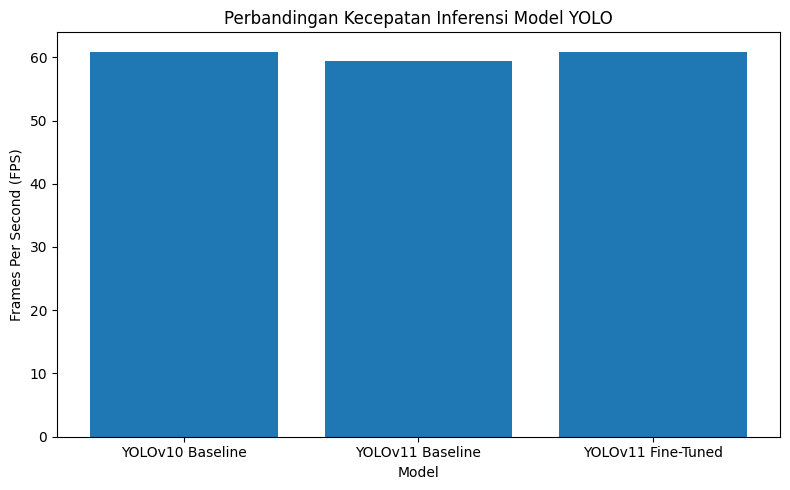

In [84]:
# Menggambar Bar Chart FPS

models_fps = ["YOLOv10 Baseline", "YOLOv11 Baseline", "YOLOv11 Fine-Tuned"]
fps_values = [fps10_baseline, fps11_baseline, fps11_finetuned]

plt.figure(figsize=(8,5))

plt.bar(models_fps, fps_values)
plt.xlabel("Model")
plt.ylabel("Frames Per Second (FPS)")
plt.title("Perbandingan Kecepatan Inferensi Model YOLO")
plt.tight_layout()
# Menyimpan grafik ke komputer
save_path = "perbandingan_performa_model_yolo_FPS.png"
plt.savefig(save_path, dpi=300)

print(f"Grafik berhasil disimpan di: {save_path}")
plt.show()

In [ ]:
# Menampilkan demonstrasi visual dan hasil komparasi kualitatif deteksi pada suatu gambar pengujian
# Directory ke gambar pengujian
test_dir = "filtered_dataset/images/test"

# Dapatkan semua file gambar
files = [f for f in os.listdir(test_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

if not files:
    raise FileNotFoundError("No images found in test folder!")

img_path = os.path.join(test_dir, random.choice(files))
print("Using test image:", img_path)
# Jalankan inferensi dan simpan hasilnya
results10_base = model10_base(img_path, save=True)
results11_base = model11_base(img_path, save=True)
results11_ft = model11_ft(img_path, save=True)
# Cetak hasil deteksi
for r in results10_base:
    for cls, conf in zip(r.boxes.cls, r.boxes.conf):
        print("YOLOv10 detections (Baseline):", model10_base.names[int(cls)], float(conf))

for r in results11_base:
    for cls, conf in zip(r.boxes.cls, r.boxes.conf):
        print("YOLOv11 detections (Baseline):", model11_base.names[int(cls)], float(conf))

for r in results11_ft:
    for cls, conf in zip(r.boxes.cls, r.boxes.conf):
        print("YOLOv11 detections (Fine-Tuned):", model11_ft.names[int(cls)], float(conf))


Using test image: filtered_dataset/images/test\11 (93).png

image 1/1 c:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Project\filtered_dataset\images\test\11 (93).png: 352x640 5 cars, 1 bus, 2 trucks, 39.5ms
Speed: 1.8ms preprocess, 39.5ms inference, 0.4ms postprocess per image at shape (1, 3, 352, 640)
Results saved to C:\Users\darre\runs\detect\predict10

image 1/1 c:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Project\filtered_dataset\images\test\11 (93).png: 352x640 4 cars, 1 bus, 2 trucks, 20.9ms
Speed: 2.0ms preprocess, 20.9ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)
Results saved to C:\Users\darre\runs\detect\predict10

image 1/1 c:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Project\filtered_dataset\images\test\11 (93).png: 352x640 4 cars, 1 bus, 1 truck, 8.6ms
Speed: 1.9ms preprocess, 8.6ms inference, 1.

In [13]:
# Jalankan inferensi pada gambar 1 pengujian dan simpan hasilnya untuk model YOLOv11 Fine-Tuned
from ultralytics import YOLO

model = YOLO("weights/YOLOv11_finetuned_best.pt")
project_path = r"C:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Record Demo Files\results"
model("images/Test1.jpg",
    save=True,
    project=project_path,
    name="",
    exist_ok=True)


image 1/1 c:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Record Demo Files\images\Test1.jpg: 384x640 5 buss, 68.0ms
Speed: 3.9ms preprocess, 68.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Record Demo Files\results\predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'bus', 2: 'truck'}
 obb: None
 orig_img: array([[[62, 53, 44],
         [62, 53, 44],
         [62, 53, 44],
         ...,
         [30, 29, 25],
         [30, 29, 25],
         [30, 29, 25]],
 
        [[62, 53, 44],
         [62, 53, 44],
         [62, 53, 44],
         ...,
         [30, 29, 25],
         [30, 29, 25],
         [30, 29, 25]],
 
        [[62, 53, 44],
         [62, 53, 44],
         [62, 53, 44],
         ...,
         [30, 29, 25],
         [30, 29, 25],
         [30, 29, 25]],
 
        ...,
 
        [[40, 35, 32],
         [40, 35, 32],
         [40, 35, 32],
         ...,
         [52, 45, 42],
         [52, 45, 42],
         [52, 45, 42]],
 
        [[40, 35, 32],
         [40, 35, 32],
         [40, 35, 32],
         ...,
         [52, 45, 42],
         [52, 45, 42],
         [52, 45, 42]],
 
        

In [14]:
# Jalankan inferensi pada gambar 2 pengujian dan simpan hasilnya untuk model YOLOv11 Fine-Tuned
from ultralytics import YOLO

model = YOLO("weights/YOLOv11_finetuned_best.pt")
project_path = r"C:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Record Demo Files\results"
model("images/Test2.jpg",
    save=True,
    project=project_path,
    name="",
    exist_ok=True)


image 1/1 c:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Record Demo Files\images\Test2.jpg: 448x640 1 bus, 70.5ms
Speed: 2.5ms preprocess, 70.5ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\darre\OneDrive\Binus Master's Degree\Semester 2 Files\Deep Learning and its Applications\Record Demo Files\results\predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'bus', 2: 'truck'}
 obb: None
 orig_img: array([[[245, 223, 182],
         [246, 224, 183],
         [248, 226, 185],
         ...,
         [249, 231, 194],
         [250, 232, 195],
         [250, 232, 195]],
 
        [[246, 224, 183],
         [247, 225, 184],
         [248, 226, 185],
         ...,
         [249, 231, 194],
         [249, 231, 194],
         [249, 231, 194]],
 
        [[247, 225, 184],
         [247, 225, 184],
         [247, 225, 184],
         ...,
         [248, 230, 193],
         [249, 231, 194],
         [249, 231, 194]],
 
        ...,
 
        [[205, 216, 230],
         [207, 218, 232],
         [205, 216, 230],
         ...,
         [197, 201, 206],
         [198, 202, 207],
         [199, 203, 208]],
 
        [[204, 215, 229],
         [204, 215, 229],
         [203, 214, 228],
         ...,